<a href="https://colab.research.google.com/github/hikaaru13/PCVK-GANJIL-TUGAS/blob/main/PCVK_Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


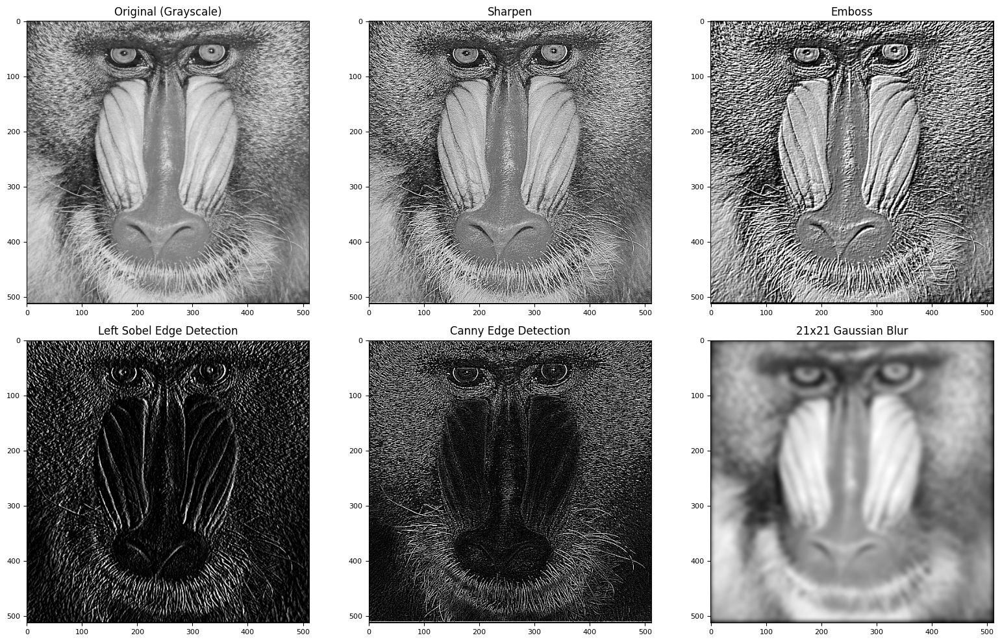

In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import math


def convolution2d(image, kernel, stride=1, padding=0):
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)

    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    out_h = (img_h - k_h) // stride + 1
    out_w = (img_w - k_w) // stride + 1

    output = np.zeros((out_h, out_w))

    for y in range(0, out_h):
        for x in range(0, out_w):
            region = image[y*stride:y*stride+k_h, x*stride:x*stride+k_w]
            output[y, x] = np.sum(region * kernel)

    output = np.clip(output, 0, 255)
    return output.astype(np.uint8)

path_gambar = '/content/drive/MyDrive/PCVK/images/mandrill.tiff'

img = cv.imread(path_gambar)


if img is None:
    print("Error: Gambar tidak ditemukan. Periksa kembali path lokasi gambar Anda!")
else:

    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


    kernel_sharpen = np.array([[0, -1, 0],
                               [-1, 5, -1],
                               [0, -1, 0]])

    kernel_emboss = np.array([[-2, -1, 0],
                              [-1, 1, 1],
                              [0, 1, 2]])

    kernel_left_sobel = np.array([[1, 0, -1],
                                  [2, 0, -2],
                                  [1, 0, -1]])

    kernel_canny = np.array([[-1, -1, -1],
                             [-1, 8, -1],
                             [-1, -1, -1]])


    kernel_size = 21
    sigma = math.sqrt(kernel_size)
    gaussian_kernel_1d = cv.getGaussianKernel(kernel_size, sigma)
    gauss_kernel = gaussian_kernel_1d @ gaussian_kernel_1d.transpose()


    res_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)
    res_emboss = convolution2d(img_gray, kernel_emboss, stride=1, padding=1)
    res_left_sobel = convolution2d(img_gray, kernel_left_sobel, stride=1, padding=1)
    res_canny = convolution2d(img_gray, kernel_canny, stride=1, padding=1)
    res_gauss = convolution2d(img_gray, gauss_kernel, stride=1, padding=10) # padding 10 untuk kernel 21x21


    titles = ['Original (Grayscale)', 'Sharpen', 'Emboss',
              'Left Sobel Edge Detection', 'Canny Edge Detection', '21x21 Gaussian Blur']
    images = [img_gray, res_sharpen, res_emboss, res_left_sobel, res_canny, res_gauss]

    plt.figure(figsize=(16, 10))
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i], fontsize=12)
        plt.tick_params(axis='both', labelsize=8)

    plt.tight_layout()
    plt.show()

Berikut ini adalah hasil tampilannya:


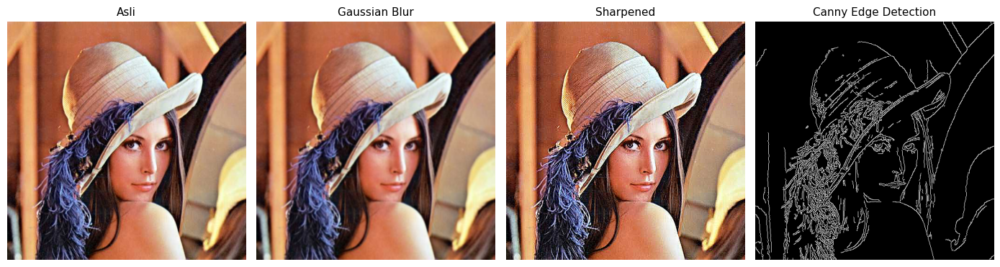

Percobaan 2:


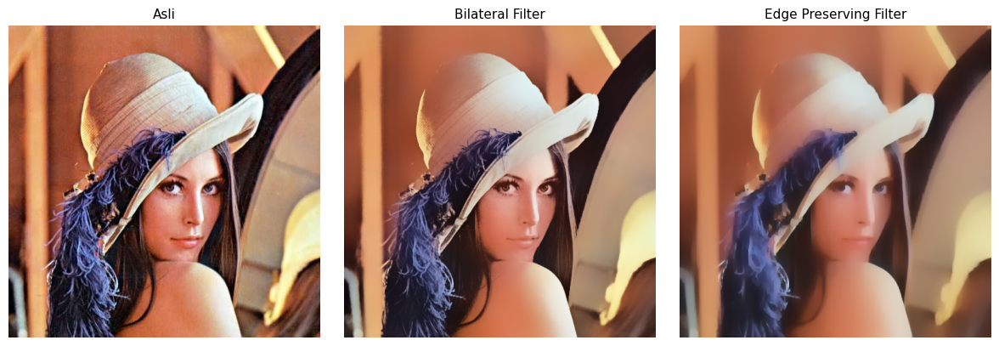

Percobaan 3:


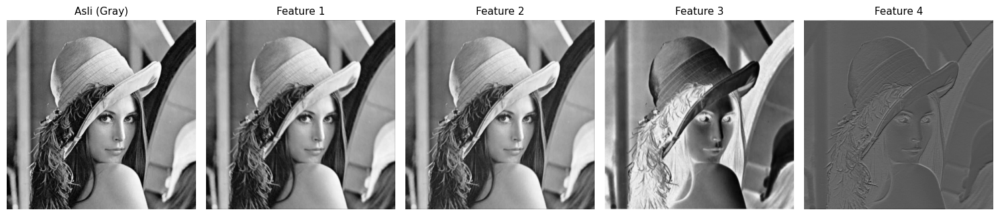

Percobaan 4:


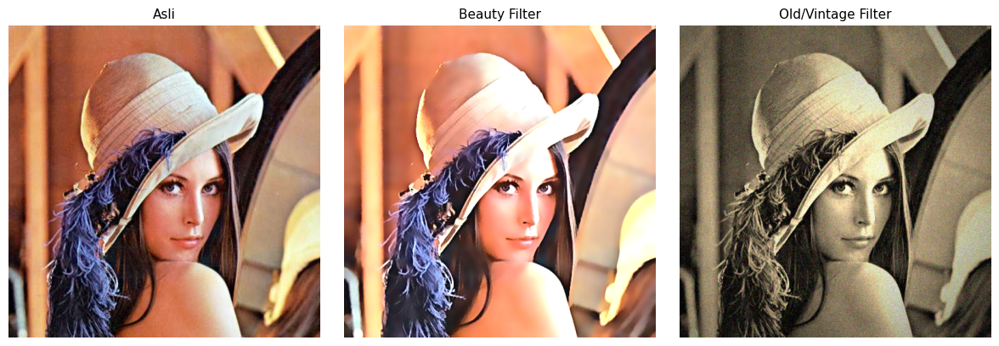

Percobaan 5:


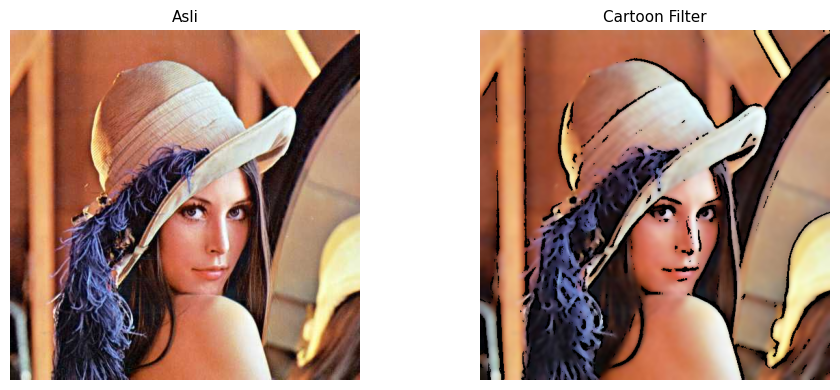

Percobaan 6:


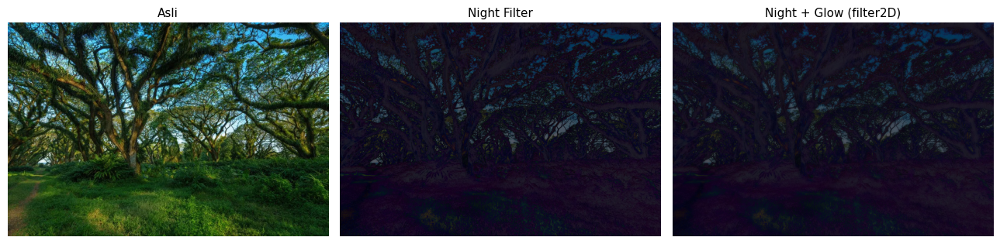

Percobaan 7:


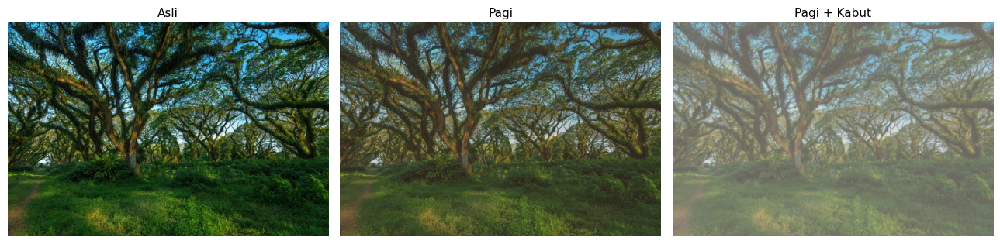

In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i+1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title, fontsize=11)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


path_lena = '/content/drive/MyDrive/PCVK/images/lena.jpg'
path_djawatan = '/content/drive/MyDrive/PCVK/images/djawatan.jpg'

img_lena = cv.imread(path_lena)
img_djawatan = cv.imread(path_djawatan)

# =========================================================
# Percobaan 1: Basic OpenCV Filters
# =========================================================
blur = cv.GaussianBlur(img_lena, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY), 100, 200)

sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv.filter2D(img_lena, -1, sharpen_kernel)

print("Berikut ini adalah hasil tampilannya:")
show_side_by_side([img_lena, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"],
                  figsize=(14, 4))

# =========================================================
# Percobaan 2: Modern OpenCV Filters
# =========================================================
bilateral = cv.bilateralFilter(img_lena, 50, 100, 100)
edge_preserve = cv.edgePreservingFilter(img_lena, flags=1, sigma_s=100, sigma_r=0.9)

print("Percobaan 2:")
show_side_by_side([img_lena, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"],
                  figsize=(12, 4))

# =========================================================
# Percobaan 3: Feature Map pada CNN
# =========================================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

torch.manual_seed(42)
model = SimpleCNN()

img_gray = cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY)
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

with torch.no_grad():
    features = model(img_tensor)

feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]

print("Percobaan 3:")
show_side_by_side([img_gray] + feature_maps,
                  ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))],
                  figsize=(15, 3.5))

# =========================================================
# Percobaan 4: Beauty dan Old/Vintage Filter
# =========================================================
smooth = cv.bilateralFilter(img_lena, d=15, sigmaColor=75, sigmaSpace=75)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened_beauty = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)
beauty = cv.convertScaleAbs(sharpened_beauty, alpha=1.2, beta=15)

sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img_lena, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

rows, cols = img_lena.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
kernel_vignette = kernel_y * kernel_x.T
mask = kernel_vignette / kernel_vignette.max()

vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask

np.random.seed(42)
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

print("Percobaan 4:")
show_side_by_side([img_lena, beauty, old_img],
                  ["Asli", "Beauty Filter", "Old/Vintage Filter"],
                  figsize=(12, 4))

# =========================================================
# Percobaan 5: Anime / Cartoon Filter
# =========================================================
gray = cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges_cartoon = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)

color = cv.bilateralFilter(img_lena, d=9, sigmaColor=200, sigmaSpace=200)
cartoon = cv.bitwise_and(color, color, mask=edges_cartoon)

print("Percobaan 5:")
show_side_by_side([img_lena, cartoon],
                  ["Asli", "Cartoon Filter"],
                  figsize=(10, 4))

# =========================================================
# Percobaan 6: Night Filter
# =========================================================
night = cv.convertScaleAbs(img_djawatan, alpha=0.6, beta=-40)
blue_tint = np.full_like(night, (50, 0, 0))  # BGR warna biru
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

kernel_glow = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel_glow)
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

print("Percobaan 6:")
show_side_by_side([img_djawatan, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"],
                  figsize=(13, 4))

# =========================================================
# Percobaan 7: Filter Suasana Pagi dan Kabut
# =========================================================
soft = cv.convertScaleAbs(img_djawatan, alpha=0.9, beta=20)
warm_tint = np.full_like(soft, (40, 70, 120))
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

kernel_haze = cv.getGaussianKernel(3, 3)
kernel_haze = kernel_haze @ kernel_haze.T
kabut = cv.filter2D(pagi, -1, kernel_haze)

white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

print("Percobaan 7:")
show_side_by_side([img_djawatan, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"],
                  figsize=(13, 4))

tugas Praktikum

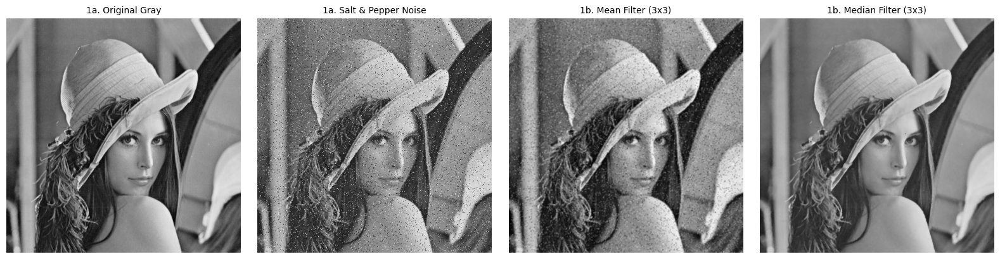

In [ ]:
# ==============================================================================
# NOMOR 1: Salt & Pepper Noise Filtering
# ==============================================================================
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img_color = cv.imread('lena.jpg')
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

# a. Menambahkan Salt and Pepper Noise
def add_salt_and_pepper_noise(image, salt_prob=0.03, pepper_prob=0.03):
    noisy_img = np.copy(image)
    # Salt (Piksel Putih = 255)
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_img[tuple(coords)] = 255

    # Pepper (Piksel Hitam = 0)
    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_img[tuple(coords)] = 0
    return noisy_img

np.random.seed(42)
img_noisy = add_salt_and_pepper_noise(img_gray)

# b. Terapkan Mean Filter (3x3) dan Median Filter (3x3)
img_mean = cv.blur(img_noisy, (3, 3))         # Mean Filter 3x3
img_median = cv.medianBlur(img_noisy, 3)     # Median Filter 3x3

# Tampilkan Hasil
titles = ["1a. Original Gray", "1a. Salt & Pepper Noise", "1b. Mean Filter (3x3)", "1b. Median Filter (3x3)"]
images = [img_gray, img_noisy, img_mean, img_median]

plt.figure(figsize=(16, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

Analisis Jawaban Nomor 1(c):Mengapa Median Filter jauh lebih bersih?Noise Salt and Pepper berupa bintik nilai ekstrem ($0$ atau $255$).Mean Filter menghitung rata-rata seluruh piksel di area kernel. Nilai ekstrem $0$ dan $255$ merusak nilai rata-rata piksel tetangga, sehingga noise tidak hilang melainkan menyebar menjadi bercak abu-abu buram.Median Filter mengurutkan nilai piksel di area kernel lalu mengambil nilai tengahnya. Nilai ekstrem $0$ dan $255$ selalu berada di ujung daftar urutan sehingga otomatis terbuang dan digantikan nilai piksel normal di sekitarnya.

2

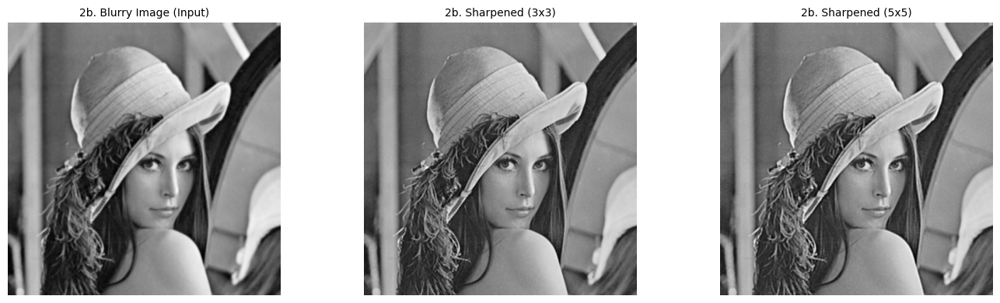

In [ ]:
# ==============================================================================
# NOMOR 2: Sharpening Kernel Size Evaluation
# ==============================================================================
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Buat gambar sedikit buram sebagai input
img_blurry = cv.GaussianBlur(img_gray, (5, 5), 0)

# a. Definisi Sharpening Kernel 3x3 dan 5x5
kernel_sharpen_3x3 = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

kernel_sharpen_5x5 = np.array([
    [-1, -1, -1, -1, -1],
    [-1,  2,  2,  2, -1],
    [-1,  2,  8,  2, -1],
    [-1,  2,  2,  2, -1],
    [-1, -1, -1, -1, -1]
]) / 8.0

# b. Terapkan Filter Penajaman
img_sharp_3x3 = cv.filter2D(img_blurry, -1, kernel_sharpen_3x3)
img_sharp_5x5 = cv.filter2D(img_blurry, -1, kernel_sharpen_5x5)

# Tampilkan Hasil
titles_2 = ["2b. Blurry Image (Input)", "2b. Sharpened (3x3)", "2b. Sharpened (5x5)"]
images_2 = [img_blurry, img_sharp_3x3, img_sharp_5x5]

plt.figure(figsize=(14, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images_2[i], cmap='gray')
    plt.title(titles_2[i], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

Evaluasi & Penentuan Nomor 2(c):Kejelasan Tepi vs. Kadar Noise:Kernel $3 \times 3$: Menajamkan garis batas objek secara wajar tanpa memunculkan bintik noise yang mengganggu.Kernel $5 \times 5$: Garis tepi sangat tajam, namun menghasilkan efek over-sharpening (muncul bayangan/halo putih di tepi) dan meningkatkan distorsi noise pada area datar.Kernel Paling Optimal: Kernel $3 \times 3$ adalah pilihan terbaik untuk penggunaan sehari-hari karena menghasilkan ketajaman yang natural tanpa merusak kualitas citra.

3

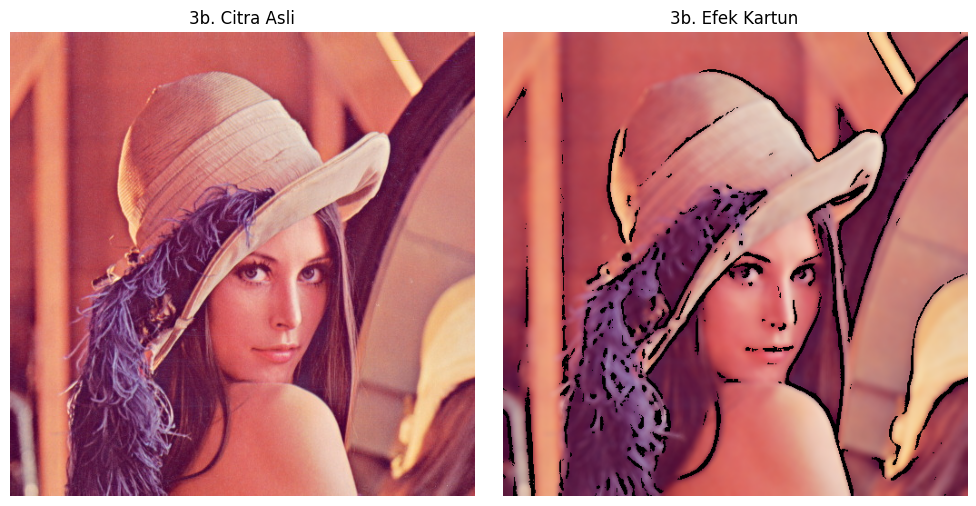

In [ ]:
# ==============================================================================
# NOMOR 3: Filter Kartun Sederhana
# ==============================================================================
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# a. Buat fungsi kustom kartun(image)
def kartun(image):
    # 1. Penghalusan warna menggunakan Bilateral Filter
    color_smooth = cv.bilateralFilter(image, d=9, sigmaColor=250, sigmaSpace=250)

    # 2. Deteksi garis tepi menggunakan Adaptive Thresholding
    gray_img = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray_img, 7)
    edges = cv.adaptiveThreshold(
        gray_blur, 255,
        cv.ADAPTIVE_THRESH_MEAN_C,
        cv.THRESH_BINARY,
        blockSize=9,
        C=9
    )

    # Konversi edges ke 3 channel (BGR)
    edges_bgr = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)

    # 3. Penggabungan (kombinasi) menggunakan operasi bitwise AND
    cartoon_img = cv.bitwise_and(color_smooth, edges_bgr)
    return cartoon_img

# b. Terapkan fungsi dan tampilkan bersebelahan
img_cartoon_result = kartun(img_color)

# Tampilkan Hasil (Ubah BGR ke RGB untuk Matplotlib)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
plt.title("3b. Citra Asli")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(img_cartoon_result, cv.COLOR_BGR2RGB))
plt.title("3b. Efek Kartun")
plt.axis('off')

plt.tight_layout()
plt.show()